In [1]:
import pandas as pd
import numpy as np

df = pd.read_parquet("data/module1_spot_v0.parquet", engine="fastparquet")

df["ts"] = pd.to_datetime(df["ts"], utc=True)
df = df.sort_values("ts").reset_index(drop=True)

# --- Returns ---
df["log_return"] = np.log(df["close"] / df["close"].shift(1))

# --- Volatility (multi-scale) ---
df["vol_5"]  = df["log_return"].rolling(5).std()
df["vol_20"] = df["log_return"].rolling(20).std()
df["vol_60"] = df["log_return"].rolling(60).std()

df["vol_compression"] = df["vol_5"] / (df["vol_20"] + 1e-8)
# --- Trend (multi-horizon returns) ---
df["ret_3"]  = df["close"].pct_change(3)
df["ret_7"]  = df["close"].pct_change(7)
df["ret_14"] = df["close"].pct_change(14)
df["momentum_decay"] = df["ret_3"] - df["ret_7"]
# --- Moving averages (trend strength proxy) ---
df["ma_10"] = df["close"].rolling(10).mean()
df["ma_30"] = df["close"].rolling(30).mean()

df["trend_strength"] = (df["ma_10"] - df["ma_30"]) / df["ma_30"]

# --- Distribution features ---
df["skew_20"] = df["log_return"].rolling(20).skew()
df["kurt_20"] = df["log_return"].rolling(20).kurt()

# --- Range / volatility proxy ---
df["hl_range"] = (df["high"] - df["low"]) / df["close"]
df["range_5"]  = df["hl_range"].rolling(5).mean()
df["range_20"] = df["hl_range"].rolling(20).mean()

df["range_expansion"] = df["range_5"] / df["range_20"]
# --- Volume features ---
vol_std = df["volume"].rolling(20).std()
df["vol_zscore"] = (df["volume"] - df["volume"].rolling(20).mean()) / (vol_std + 1e-8)
df["up_days_10"] = (df["log_return"] > 0).rolling(10).sum()
df["trend_persistence"] = df["up_days_10"] / 10

df["trend_vol_interaction"] = df["trend_strength"] * df["vol_zscore"]
# --- Cleanup ---
df = df.dropna().reset_index(drop=True)

In [2]:
# --- Parameters ---
HOLDING = 5
TP_MULT = 2.0
SL_MULT = 1.0

df = df.copy()

# --- Volatility (use vol_20 as sigma) ---
df["sigma"] = df["log_return"].rolling(20).std()

# --- Pre-allocate ---
labels = []
exit_times = []
returns = []

close = df["close"].values
ts = df["ts"].values
sigma = df["sigma"].values

n = len(df)

for i in range(n - HOLDING):
    
    entry_px = close[i]
    entry_sigma = sigma[i]
    
    if np.isnan(entry_sigma):
        labels.append(np.nan)
        exit_times.append(pd.NaT)
        returns.append(np.nan)
        continue
    
    tp = entry_px * (1 + TP_MULT * entry_sigma)
    sl = entry_px * (1 - SL_MULT * entry_sigma)
    
    labels = [np.nan] * n
exit_times = [pd.NaT] * n
returns = [np.nan] * n

for i in range(n - HOLDING):
    
    entry_px = close[i]
    entry_sigma = sigma[i]
    
    if np.isnan(entry_sigma):
        continue
    
    tp = entry_px * (1 + TP_MULT * entry_sigma)
    sl = entry_px * (1 - SL_MULT * entry_sigma)
    
    label = 0
    exit_time = ts[i + HOLDING]
    ret = 0
    
    for j in range(1, HOLDING + 1):
        px = close[i + j]
        
        if px >= tp:
            label = 1
            exit_time = ts[i + j]
            ret = (px - entry_px) / entry_px
            break
        
        elif px <= sl:
            label = 0
            exit_time = ts[i + j]
            ret = (px - entry_px) / entry_px
            break
        
        if j == HOLDING:
            px = close[i + j]
            ret = (px - entry_px) / entry_px
    
    labels[i] = label
    exit_times[i] = exit_time
    returns[i] = ret

# --- Assign ---
df["tb_label"] = labels
df["tb_exit_time"] = exit_times
df["tb_return"] = returns

# --- Cleanup ---
df = df.dropna(subset=["tb_label"]).reset_index(drop=True)

In [3]:
df["tb_label"].value_counts(normalize=True)

tb_label
0.0    0.759287
1.0    0.240713
Name: proportion, dtype: float64

In [4]:
# --- Parameters ---
HOLDING = 5
TP_MULT = 2.0   # profit (downward move)
SL_MULT = 1.0   # loss (upward move)

df = df.copy()

df["sigma"] = df["log_return"].rolling(20).std()

labels_short = [np.nan] * len(df)
exit_times_short = [pd.NaT] * len(df)
returns_short = [np.nan] * len(df)

close = df["close"].values
ts = df["ts"].values
sigma = df["sigma"].values

n = len(df)

for i in range(n - HOLDING):
    
    entry_px = close[i]
    entry_sigma = sigma[i]
    
    if np.isnan(entry_sigma):
        continue
    
    # --- NOTE inversion ---
    tp = entry_px * (1 - TP_MULT * entry_sigma)   # downward profit
    sl = entry_px * (1 + SL_MULT * entry_sigma)   # upward loss
    
    label = 0
    exit_time = ts[i + HOLDING]
    ret = 0
    
    for j in range(1, HOLDING + 1):
        px = close[i + j]
        
        # TP (price falls)
        if px <= tp:
            label = 1
            exit_time = ts[i + j]
            ret = (entry_px - px) / entry_px   # <-- IMPORTANT (short return)
            break
        
        # SL (price rises)
        elif px >= sl:
            label = 0
            exit_time = ts[i + j]
            ret = (entry_px - px) / entry_px
            break
        
        # timeout
        if j == HOLDING:
            px = close[i + j]
            ret = (entry_px - px) / entry_px
    
    labels_short[i] = label
    exit_times_short[i] = exit_time
    returns_short[i] = ret

# --- Assign ---
df["tb_label_short"] = labels_short
df["tb_exit_time_short"] = exit_times_short
df["tb_return_short"] = returns_short

df = df.dropna(subset=["tb_label_short"]).reset_index(drop=True)

In [5]:
# --- Rolling drawdown ---
df["roll_max_20"] = df["close"].rolling(20).max()
df["drawdown_20"] = (df["close"] - df["roll_max_20"]) / df["roll_max_20"]

# --- Volatility spike ---
df["vol_spike"] = df["vol_5"] / df["vol_20"]

# --- Smooth extreme noise ---
df["vol_spike"] = df["vol_spike"].clip(upper=5)
df["ma_50"] = df["close"].rolling(50).mean()
df["ma_200"] = df["close"].rolling(200).mean()

df["macro_trend"] = (df["ma_50"] > df["ma_200"]).astype(int)
# --- Risk regime (crash / unstable) ---
df["risk_regime"] = (
    (df["drawdown_20"] < -0.10) |
    (df["vol_spike"] > 1.5) |
    (df["macro_trend"] == 0)   # <-- NEW
).astype(int)

df["strong_regime"] = (
    (df["skew_20"] > df["skew_20"].quantile(0.7)) &
    (df["trend_strength"] > df["trend_strength"].quantile(0.7)) &
    (df["vol_zscore"] > 0)
).astype(int)

In [6]:
FEATURES = [
    "skew_20",
    "kurt_20",
    "ret_14",
    "ret_7",
    "trend_strength",

    "momentum_decay",
    "vol_compression",
    "trend_persistence",
    "range_expansion",
    "vol_zscore",
    "trend_vol_interaction",

    "drawdown_20",
    "vol_spike",
    "macro_trend",
    "strong_regime"
]

sep = df.groupby("tb_label")[FEATURES].mean().T
sep["diff"] = sep[1] - sep[0]

sep.sort_values("diff", ascending=False)

tb_label,0.0,1.0,diff
skew_20,-0.009563,0.176433,0.185995
vol_zscore,-0.029404,0.125173,0.154576
macro_trend,0.483384,0.576433,0.093049
strong_regime,0.059919,0.103503,0.043584
ret_14,0.015419,0.053813,0.038394
trend_persistence,0.507351,0.535987,0.028636
range_expansion,0.995426,1.018373,0.022947
ret_7,0.006800,0.027239,0.020439
trend_strength,0.006406,0.025046,0.018640
drawdown_20,-0.084362,-0.066707,0.017654


In [7]:
df = df.dropna(subset=FEATURES + ["tb_label", "tb_label_short"])

X = df[FEATURES]

y_long  = df["tb_label"]
y_short = df["tb_label_short"]

In [11]:
from xgboost import XGBClassifier
import numpy as np
import pandas as pd

# -----------------------
# DYNAMIC EXIT FUNCTION
# -----------------------
def simulate_trade_dynamic(df, i, signal, model_long, model_short, FEATURES,
                           TP=0.02, SL=0.01, MAX_HOLD=10):
    
    entry_price = df.iloc[i]["close"]
    exit_price = entry_price 
    
    if signal == 1:
        tp, sl = entry_price * (1 + TP), entry_price * (1 - SL)
    else:
        tp, sl = entry_price * (1 - TP), entry_price * (1 + SL)
    
    # Pre-calculate quantile outside the loop for performance
    trend_thresh = df["trend_strength"].abs().quantile(0.6)
    
    for j in range(i + 1, min(i + MAX_HOLD + 1, len(df))):
        price = df.iloc[j]["close"]
        p_long = df.iloc[j]["prob_long"]
        p_short = df.iloc[j]["prob_short"]
        trend = df.iloc[j]["trend_strength"]
        momentum_decay = df.iloc[j]["momentum_decay"]
        
        # 1. HARD TP/SL CHECK
        if signal == 1:
            if price >= tp or price <= sl:
                exit_price = price
                break
        else:
            if price <= tp or price >= sl:
                exit_price = price
                break
        
        # 2. MODEL-BASED EXIT (MUST BE INSIDE THE LOOP)
        is_profitable = (signal == 1 and price > entry_price) or (signal == -1 and price < entry_price)
        
        if not is_profitable:
            # Confidence lost or momentum collapse
            if (signal == 1 and p_long < 0.20) or (signal == -1 and p_short < 0.20) or (momentum_decay < -0.005):
                exit_price = price
                break
        else:
            # Winning trade logic: Relax exit if trend is strong
            if abs(trend) > trend_thresh:
                if (signal == 1 and (p_short - p_long) > 0.15) or (signal == -1 and (p_long - p_short) > 0.15):
                    exit_price = price
                    break
            else:
                if (signal == 1 and (p_short - p_long) > 0.10) or (signal == -1 and (p_long - p_short) > 0.10):
                    exit_price = price
                    break
        
        exit_price = price # Update exit_price if loop continues to next bar

    # RETURN LOGIC
    return (exit_price - entry_price) / entry_price if signal == 1 else (entry_price - exit_price) / entry_price


# -----------------------
# WALK FORWARD
# -----------------------
df["year"] = df["ts"].dt.year
years = sorted(df["year"].unique())

results = []
all_trades = []

MIN_TRAIN_YEARS = 3

for k in range(MIN_TRAIN_YEARS, len(years)):
    
    train_years = years[:k]
    test_year = years[k]
    
    train = df[df["year"].isin(train_years)].copy()
    test  = df[df["year"] == test_year].copy()
    
    if len(test) == 0:
        continue
    
    # 🔥 CRITICAL FIX
    test = test.reset_index(drop=True)
    
    # --- Data ---
    X_train = train[FEATURES]
    y_train_long  = train["tb_label"]
    y_train_short = train["tb_label_short"]
    
    X_test = test[FEATURES]
    
    # --- Models ---
    model_long = XGBClassifier(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss"
    )
    
    model_short = XGBClassifier(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss"
    )
    
    model_long.fit(X_train, y_train_long)
    model_short.fit(X_train, y_train_short)
    
    # --- Predictions ---
    test["prob_long"]  = model_long.predict_proba(X_test)[:, 1]
    test["prob_short"] = model_short.predict_proba(X_test)[:, 1]
    
    # --- DSS ---
    edge = test["prob_long"] - test["prob_short"]
    
    test["signal"] = 0
    
    test.loc[(edge > 0.10) & (test["prob_long"] > 0.30), "signal"] = 1
    test.loc[(edge < -0.10) & (test["prob_short"] > 0.30), "signal"] = -1
    
    # -----------------------
    # RETURNS (dynamic)
    # -----------------------
    test["ret"] = 0.0
    
    for i in range(len(test)):
        sig = test.loc[i, "signal"]
        
        if sig == 0:
            continue
        
        test.loc[i, "ret"] = simulate_trade_dynamic(
            test, i, sig,
            model_long, model_short,
            FEATURES
        )
    
    trades = test[test["signal"] != 0].copy()
    
    if len(trades) == 0:
        continue
    
    trades = trades.sort_values("ts")
    
    # --- Equity ---
    trades["cum"] = trades["ret"].cumsum()
    trades["peak"] = trades["cum"].cummax()
    trades["dd"] = trades["cum"] - trades["peak"]
    
    results.append({
        "year": test_year,
        "trades": len(trades),
        "mean_ret": trades["ret"].mean(),
        "sharpe": (
            trades["ret"].mean() / trades["ret"].std() * np.sqrt(252)
            if trades["ret"].std() > 0 else np.nan
        ),
        "max_dd": trades["dd"].min()
    })
    
    all_trades.append(trades)

# -----------------------
# FINAL SUMMARY
# -----------------------
wf_summary = pd.DataFrame(results)

wf_equity = pd.concat(all_trades).sort_values("ts")

wf_equity["cum"] = wf_equity["ret"].cumsum()
wf_equity["peak"] = wf_equity["cum"].cummax()
wf_equity["dd"] = wf_equity["cum"] - wf_equity["peak"]

overall = {
    "mean_ret": wf_equity["ret"].mean(),
    "sharpe": (
        wf_equity["ret"].mean() / wf_equity["ret"].std() * np.sqrt(252)
        if wf_equity["ret"].std() > 0 else np.nan
    ),
    "max_dd": wf_equity["dd"].min(),
    "trades": len(wf_equity)
}

wf_summary, overall

(   year  trades  mean_ret    sharpe    max_dd
 0  2020     138  0.001599  0.588741 -0.611744
 1  2021     141  0.002369  0.726142 -0.600969
 2  2022     115  0.003688  1.542235 -0.267835
 3  2023     120  0.002813  1.438449 -0.601259
 4  2024     137  0.008164  3.897161 -0.251505
 5  2025       7 -0.010205 -4.443655 -0.153686,
 {'mean_ret': np.float64(0.0035918219156613686),
  'sharpe': np.float64(1.4112258319512652),
  'max_dd': np.float64(-0.693978734236544),
  'trades': 658})

In [12]:
# -----------------------
# PREP UNSEEN (features must match training)
# -----------------------
unseen_df = pd.read_parquet("data/unseen_data.parquet")
unseen_df["ts"] = pd.to_datetime(unseen_df["ts"], utc=True)
unseen_df = unseen_df.sort_values("ts").reset_index(drop=True)

# --- Feature engineering (same as training) ---
unseen_df["log_return"] = np.log(unseen_df["close"] / unseen_df["close"].shift(1))

unseen_df["vol_5"]  = unseen_df["log_return"].rolling(5).std()
unseen_df["vol_20"] = unseen_df["log_return"].rolling(20).std()
unseen_df["vol_60"] = unseen_df["log_return"].rolling(60).std()
unseen_df["vol_compression"] = unseen_df["vol_5"] / (unseen_df["vol_20"] + 1e-8)

unseen_df["ret_3"]  = unseen_df["close"].pct_change(3)
unseen_df["ret_7"]  = unseen_df["close"].pct_change(7)
unseen_df["ret_14"] = unseen_df["close"].pct_change(14)
unseen_df["momentum_decay"] = unseen_df["ret_3"] - unseen_df["ret_7"]

unseen_df["ma_10"] = unseen_df["close"].rolling(10).mean()
unseen_df["ma_30"] = unseen_df["close"].rolling(30).mean()
unseen_df["trend_strength"] = (unseen_df["ma_10"] - unseen_df["ma_30"]) / unseen_df["ma_30"]

unseen_df["skew_20"] = unseen_df["log_return"].rolling(20).skew()
unseen_df["kurt_20"] = unseen_df["log_return"].rolling(20).kurt()

unseen_df["hl_range"] = (unseen_df["high"] - unseen_df["low"]) / unseen_df["close"]
unseen_df["range_5"]  = unseen_df["hl_range"].rolling(5).mean()
unseen_df["range_20"] = unseen_df["hl_range"].rolling(20).mean()
unseen_df["range_expansion"] = unseen_df["range_5"] / (unseen_df["range_20"] + 1e-8)

vol_std = unseen_df["volume"].rolling(20).std()
unseen_df["vol_zscore"] = (
    (unseen_df["volume"] - unseen_df["volume"].rolling(20).mean()) / (vol_std + 1e-8)
)

unseen_df["up_days_10"] = (unseen_df["log_return"] > 0).rolling(10).sum()
unseen_df["trend_persistence"] = unseen_df["up_days_10"] / 10

unseen_df["trend_vol_interaction"] = unseen_df["trend_strength"] * unseen_df["vol_zscore"]

unseen_df["roll_max_20"] = unseen_df["close"].rolling(20).max()
unseen_df["drawdown_20"] = (unseen_df["close"] - unseen_df["roll_max_20"]) / unseen_df["roll_max_20"]

unseen_df["vol_spike"] = unseen_df["vol_5"] / (unseen_df["vol_20"] + 1e-8)
unseen_df["vol_spike"] = unseen_df["vol_spike"].clip(upper=5)

unseen_df["ma_50"] = unseen_df["close"].rolling(50).mean()
unseen_df["ma_200"] = unseen_df["close"].rolling(200).mean()
unseen_df["macro_trend"] = (unseen_df["ma_50"] > unseen_df["ma_200"]).astype(int)

unseen_df["strong_regime"] = (
    (unseen_df["skew_20"] > unseen_df["skew_20"].quantile(0.7)) &
    (unseen_df["trend_strength"] > unseen_df["trend_strength"].quantile(0.7))
).astype(int)

# --- Triple barrier (same params as training) ---
TP, SL, MAX_HOLD = 0.02, 0.01, 5
unseen_df["tb_return"] = np.nan
unseen_df["tb_return_short"] = np.nan

close = unseen_df["close"].values
for i in range(len(unseen_df)):
    entry = close[i]
    tp_l, sl_l = entry*(1+TP), entry*(1-SL)
    tp_s, sl_s = entry*(1-TP), entry*(1+SL)
    end = min(i + MAX_HOLD, len(unseen_df) - 1)
    exit_l, exit_s = entry, entry

    for j in range(i+1, end+1):
        p = close[j]
        if p >= tp_l or p <= sl_l:
            exit_l = p; break
        if p <= tp_s or p >= sl_s:
            exit_s = p; break
        exit_l, exit_s = p, p

    unseen_df.loc[i, "tb_return"] = (exit_l - entry) / entry
    unseen_df.loc[i, "tb_return_short"] = (entry - exit_s) / entry

# --- Clean ---
unseen_df = unseen_df.dropna(subset=FEATURES + ["tb_return", "tb_return_short"]).reset_index(drop=True)

# -----------------------
# TRAIN ON FULL DATA
# -----------------------
X_full = df[FEATURES]
y_full_long  = df["tb_label"]
y_full_short = df["tb_label_short"]

model_long_full = XGBClassifier(
    n_estimators=400, max_depth=4, learning_rate=0.03,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, eval_metric="logloss"
)

model_short_full = XGBClassifier(
    n_estimators=400, max_depth=4, learning_rate=0.03,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, eval_metric="logloss"
)

model_long_full.fit(X_full, y_full_long)
model_short_full.fit(X_full, y_full_short)

# -----------------------
# PREDICT ON UNSEEN
# -----------------------
X_unseen = unseen_df[FEATURES]

unseen_df["prob_long"]  = model_long_full.predict_proba(X_unseen)[:, 1]
unseen_df["prob_short"] = model_short_full.predict_proba(X_unseen)[:, 1]

# --- DSS ---
edge = unseen_df["prob_long"] - unseen_df["prob_short"]

unseen_df["signal"] = 0
unseen_df.loc[(edge > 0.10) & (unseen_df["prob_long"] > 0.30), "signal"] = 1
unseen_df.loc[(edge < -0.10) & (unseen_df["prob_short"] > 0.30), "signal"] = -1

# --- Returns ---
unseen_df["ret"] = 0.0

for i in range(len(unseen_df)):
    sig = unseen_df.loc[i, "signal"]
    
    if sig == 0:
        continue
    
    unseen_df.loc[i, "ret"] = simulate_trade_dynamic(
        unseen_df, i, sig,
        model_long_full, model_short_full,
        FEATURES
    )
    
trades_u = unseen_df[unseen_df["signal"] != 0].copy()
trades_u = trades_u.sort_values("ts")
# --- Metrics ---
summary_u = {
    "trades": len(trades_u),
    "total_pnl": trades_u["ret"].sum(),
    "mean_ret": trades_u["ret"].mean(),
    "win_rate": (trades_u["ret"] > 0).mean(),
    "avg_win": trades_u[trades_u["ret"] > 0]["ret"].mean(),
    "avg_loss": trades_u[trades_u["ret"] <= 0]["ret"].mean(),
}
summary_u["profit_factor"] = (
    abs(summary_u["avg_win"] / summary_u["avg_loss"])
    if summary_u["avg_loss"] != 0 else np.nan
)

# --- Equity / DD ---
trades_u["cum"] = trades_u["ret"].cumsum()
trades_u["peak"] = trades_u["cum"].cummax()
trades_u["dd"] = trades_u["cum"] - trades_u["peak"]

print(summary_u)
print("Unseen Max DD:", trades_u["dd"].min())

{'trades': 97, 'total_pnl': np.float64(0.015670849307492157), 'mean_ret': np.float64(0.00016155514749991915), 'win_rate': np.float64(0.3711340206185567), 'avg_win': np.float64(0.03083350975462324), 'avg_loss': np.float64(-0.017939926259982693), 'profit_factor': np.float64(1.7187088345731576)}
Unseen Max DD: -0.2688723368562814


In [13]:
# pick few trades to inspect
sample_trades = trades_u.head(5).copy()

sample_trades[["ts", "signal", "prob_long", "prob_short", "ret"]]

,ts,signal,prob_long,prob_short,ret
0,2025-02-28 00:00:00+00:00,1,0.509491,0.200321,0.020327
3,2025-03-03 00:00:00+00:00,-1,0.132099,0.309005,-0.012310
7,2025-03-07 00:00:00+00:00,-1,0.190871,0.360228,0.069899
10,2025-03-10 00:00:00+00:00,1,0.439317,0.243281,0.055183
14,2025-03-14 00:00:00+00:00,-1,0.232187,0.364478,-0.000319


In [14]:
import matplotlib.pyplot as plt

def plot_trade(df, trade_idx, window=15):
    
    row = df.loc[trade_idx]
    entry_time = row["ts"]
    entry_price = row["close"]
    signal = row["signal"]
    
    # window around trade
    start = max(0, trade_idx - window)
    end   = min(len(df)-1, trade_idx + window)
    
    sub = df.iloc[start:end].copy()
    
    # --- TP / SL ---
    TP = 0.02
    SL = 0.01
    
    if signal == 1:
        tp = entry_price * (1 + TP)
        sl = entry_price * (1 - SL)
    else:
        tp = entry_price * (1 - TP)
        sl = entry_price * (1 + SL)
    
    # --- find exit ---
    exit_price = entry_price
    exit_idx = trade_idx
    
    for j in range(trade_idx+1, min(trade_idx+6, len(df))):
        p = df.loc[j, "close"]
        
        if signal == 1:
            if p >= tp or p <= sl:
                exit_price = p
                exit_idx = j
                break
        else:
            if p <= tp or p >= sl:
                exit_price = p
                exit_idx = j
                break
        
        exit_price = p
        exit_idx = j
    
    exit_time = df.loc[exit_idx, "ts"]
    
    # --- plot ---
    plt.figure(figsize=(10,5))
    
    plt.plot(sub["ts"], sub["close"], label="Price")
    
    # entry
    plt.scatter(entry_time, entry_price, color="blue", s=100, label="Entry")
    
    # exit
    plt.scatter(exit_time, exit_price, color="black", s=100, label="Exit")
    
    # TP / SL lines
    plt.axhline(tp, linestyle="--", label="TP")
    plt.axhline(sl, linestyle="--", label="SL")
    
    title = (
    f"Signal={signal} | "
    f"P_long={row['prob_long']:.2f} | "
    f"P_short={row['prob_short']:.2f} | "
    f"Edge={(row['prob_long'] - row['prob_short']):.2f} | "
    f"Ret={row['ret']:.4f}"
    )
    
    cf_ret = row["tb_return_short"] if signal == 1 else row["tb_return"]

    text = (
        f"Actual: {row['ret']:.3f}\n"
        f"Opposite: {cf_ret:.3f}"
    )
    # counterfactual return
    color = "green" if cf_ret > row["ret"] else "red"

    plt.annotate(
        f"A: {row['ret']:.3f} | CF: {cf_ret:.3f}",
        (entry_time, entry_price),
        textcoords="offset points",
        xytext=(10, -30),
        fontsize=10,
        color=color,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7),
        arrowprops=dict(arrowstyle="->", color=color)
    )
    
    plt.title(title)
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

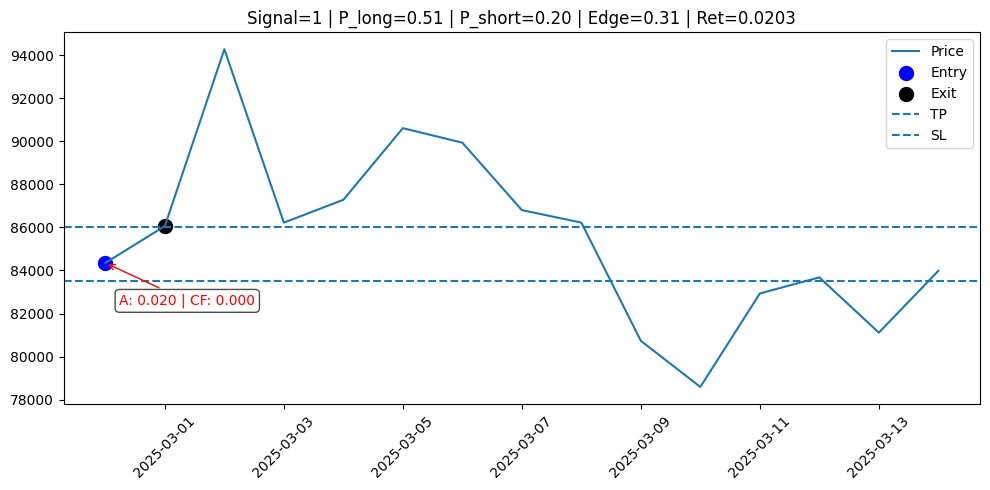

In [15]:
# IMPORTANT: use original unseen_df (not trades subset)
plot_trade(unseen_df.reset_index(drop=True), trade_idx=trades_u.index[0])

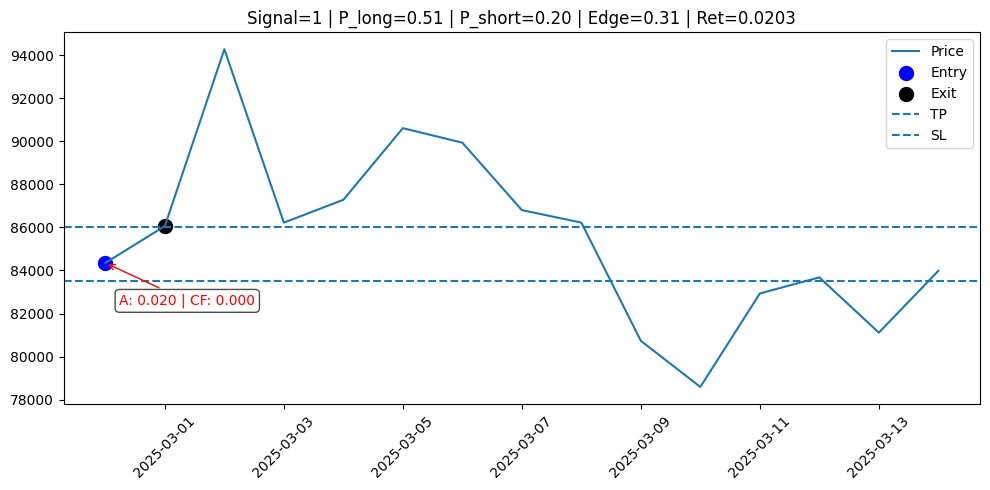

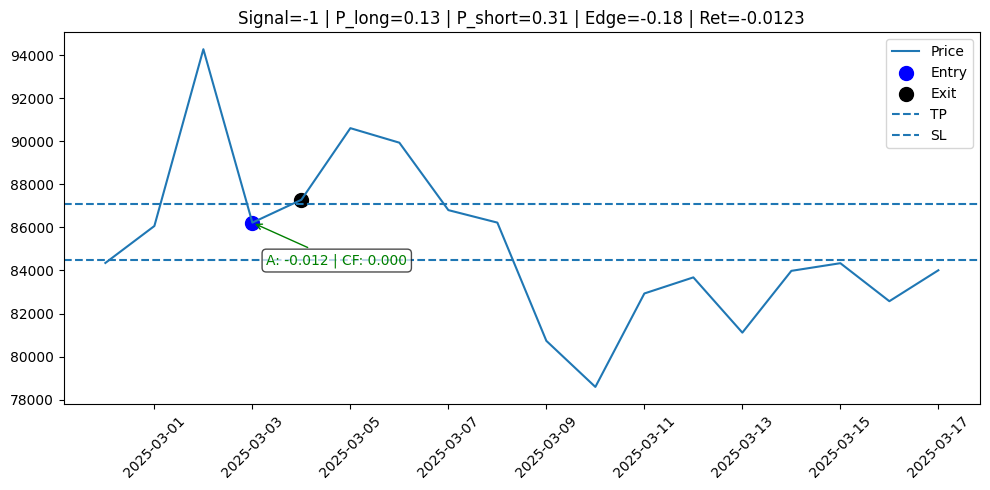

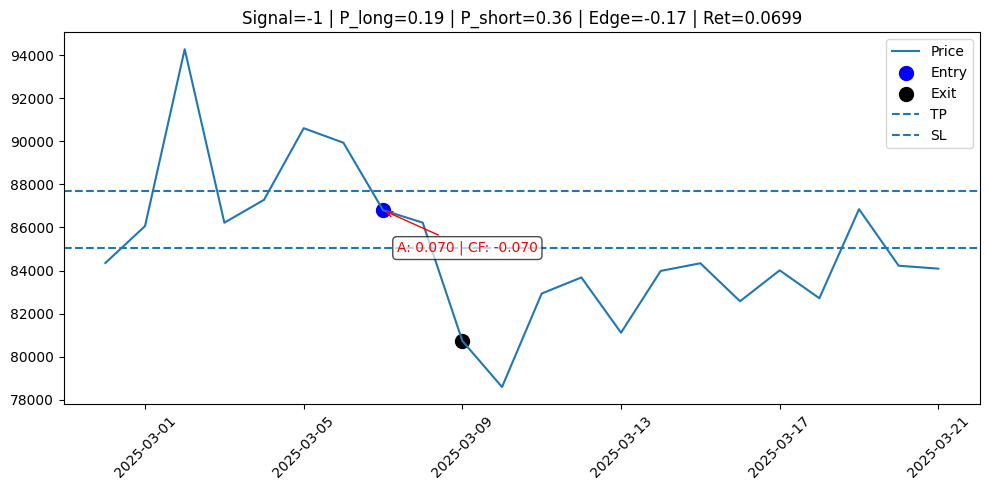

In [16]:
for idx in trades_u.index[:3]:
    plot_trade(unseen_df.reset_index(drop=True), idx)

In [17]:
# sort by worst returns
worst_trades = trades_u.sort_values("ret").head(5)

worst_trades[["ts", "signal", "prob_long", "prob_short", "ret"]]


,ts,signal,prob_long,prob_short,ret
223,2025-10-09 00:00:00+00:00,1,0.311982,0.182169,-0.073054
264,2025-11-19 00:00:00+00:00,1,0.374002,0.095044,-0.053713
18,2025-03-18 00:00:00+00:00,-1,0.074751,0.415610,-0.049941
33,2025-04-02 00:00:00+00:00,1,0.440982,0.187191,-0.049521
83,2025-05-22 00:00:00+00:00,1,0.364820,0.239624,-0.039195


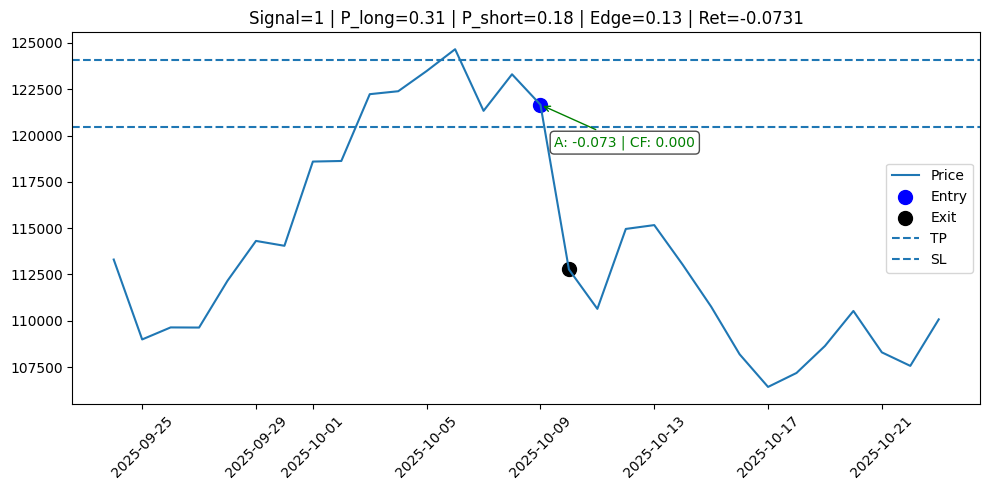

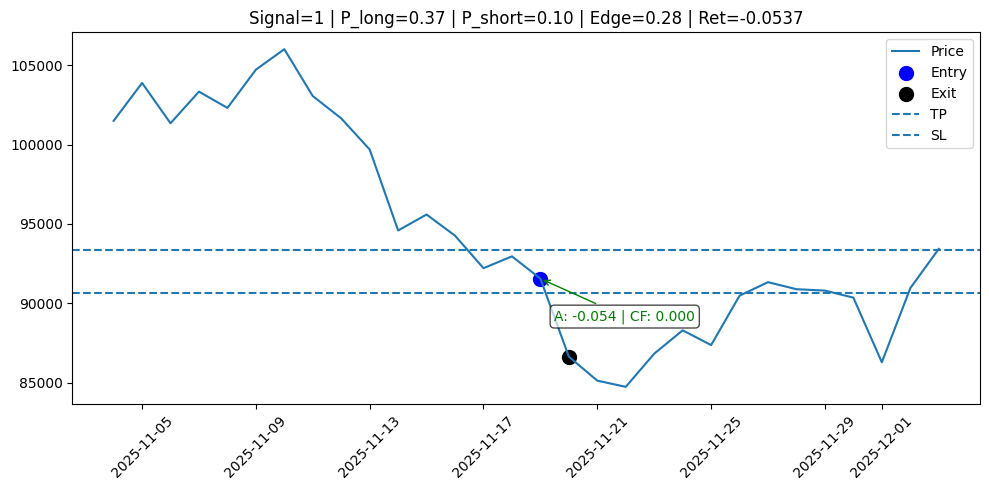

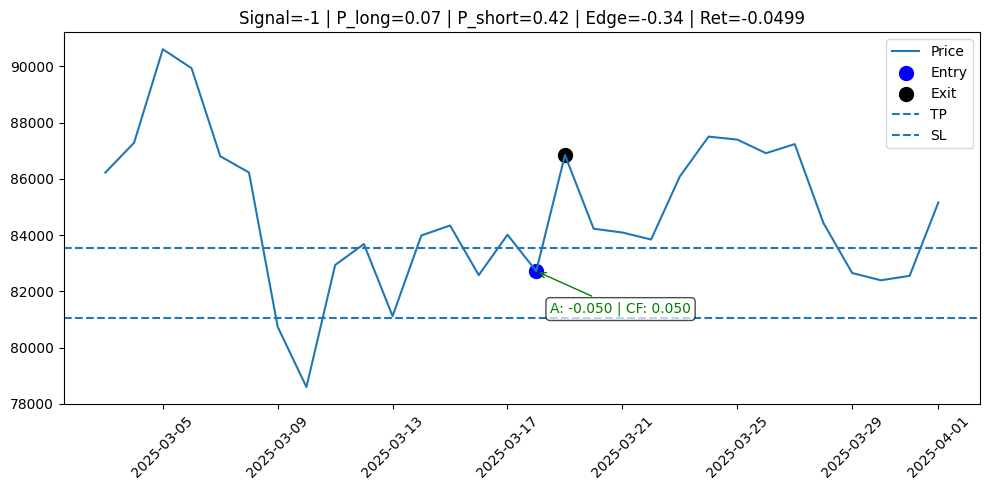

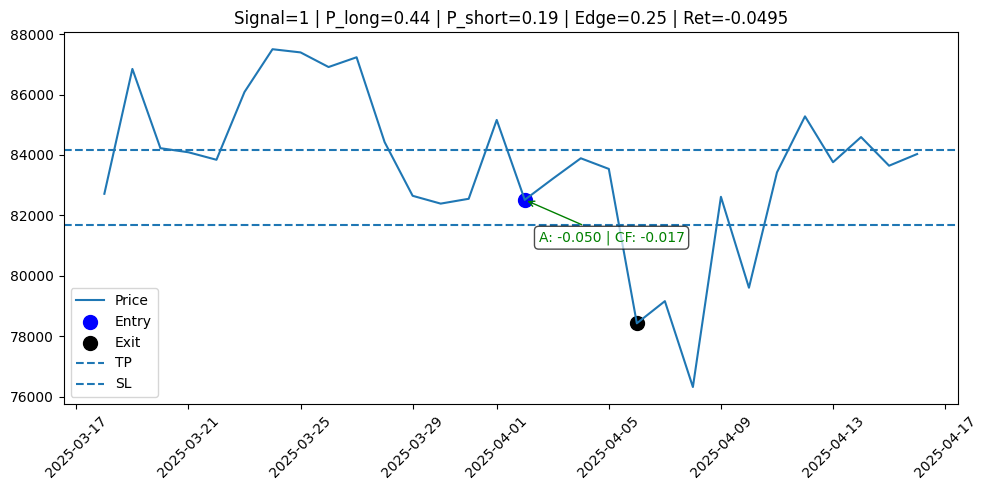

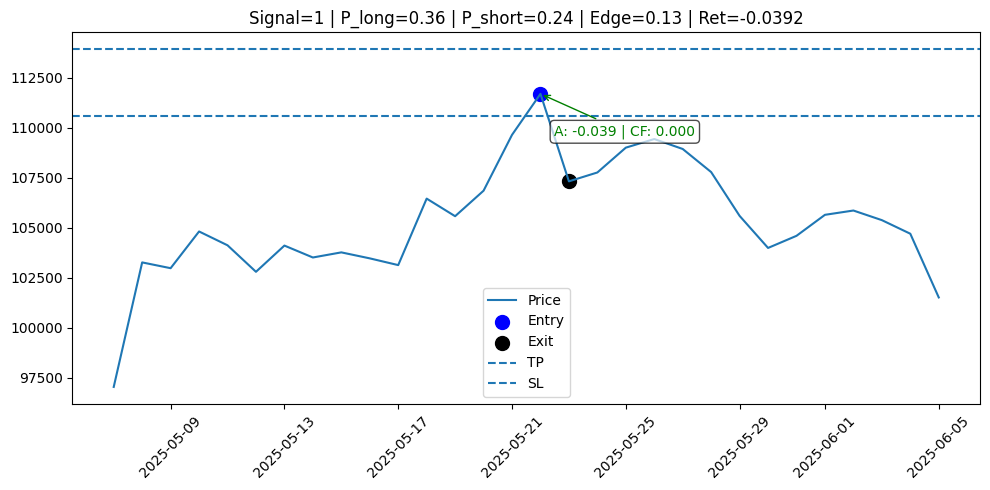

In [18]:
for idx in worst_trades.index:
    plot_trade(unseen_df.reset_index(drop=True), idx)

In [19]:
# sort by worst returns
best_trades = trades_u.sort_values("ret").tail(5)

best_trades[["ts", "signal", "prob_long", "prob_short", "ret"]]


,ts,signal,prob_long,prob_short,ret
274,2025-11-29 00:00:00+00:00,-1,0.078906,0.324584,0.049739
10,2025-03-10 00:00:00+00:00,1,0.439317,0.243281,0.055183
272,2025-11-27 00:00:00+00:00,-1,0.090903,0.324111,0.055269
52,2025-04-21 00:00:00+00:00,1,0.341825,0.091404,0.067722
7,2025-03-07 00:00:00+00:00,-1,0.190871,0.360228,0.069899


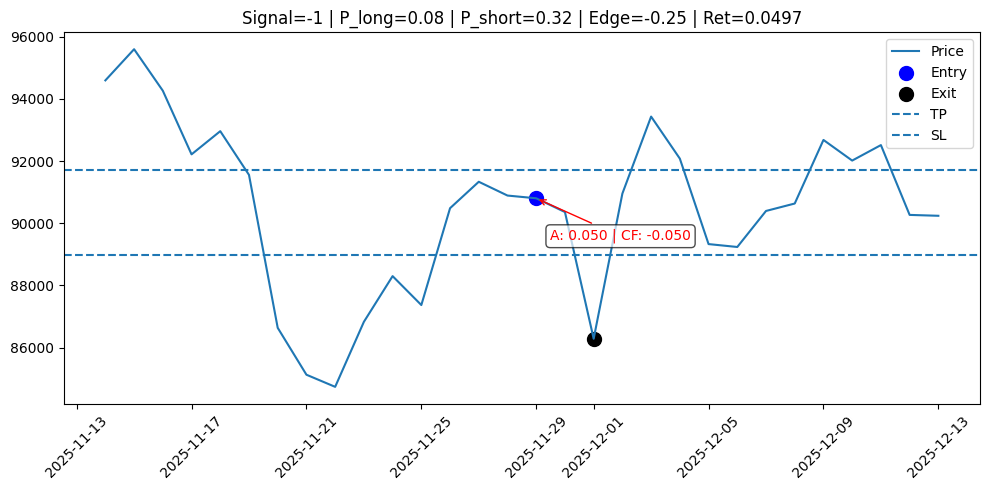

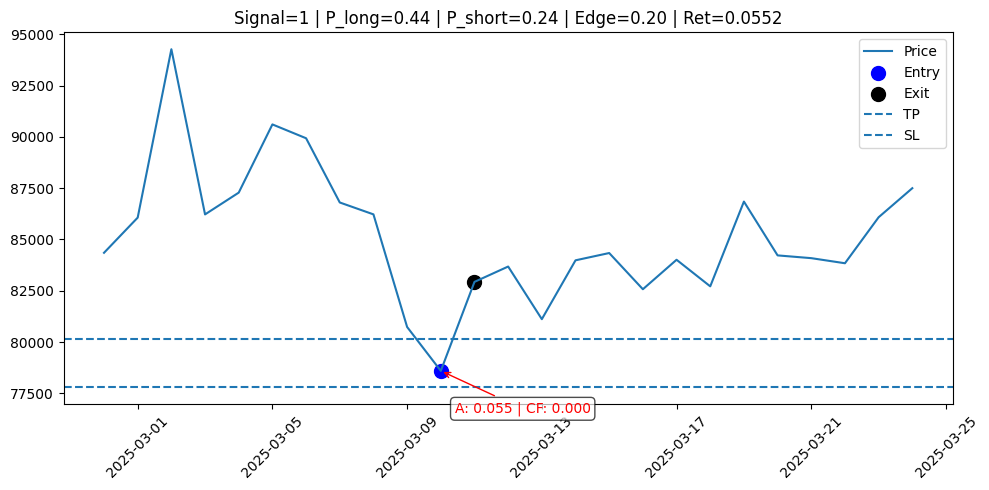

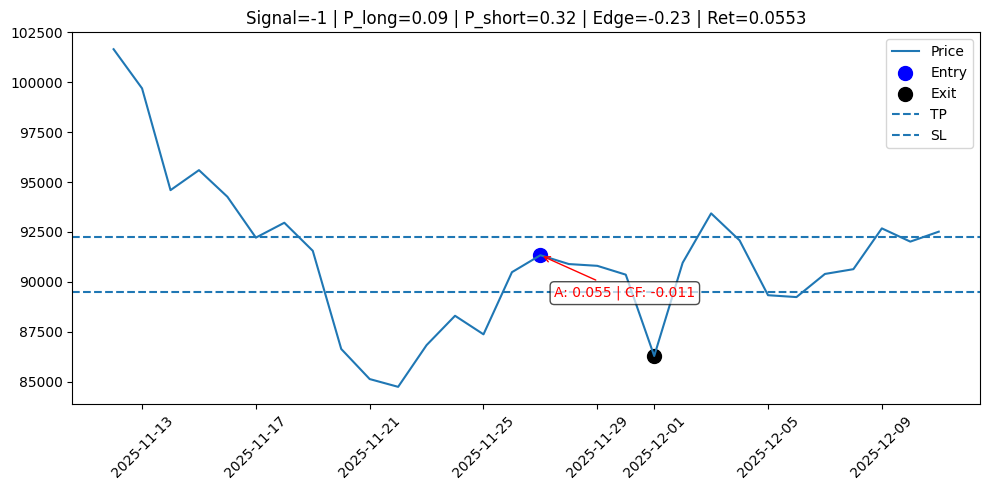

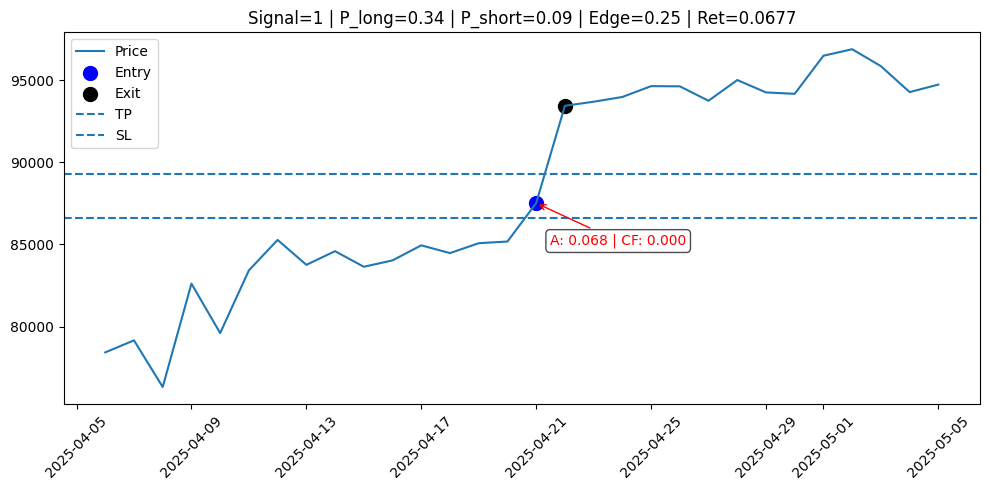

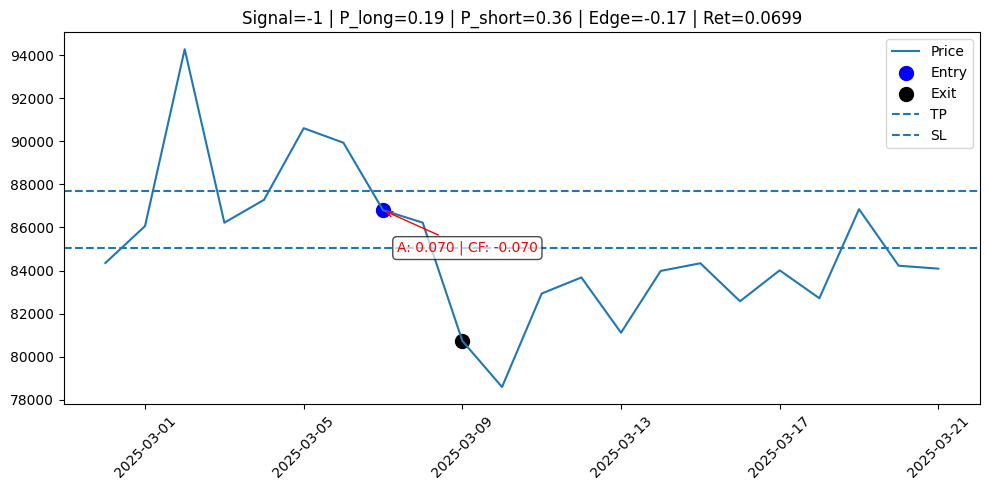

In [20]:
for idx in best_trades.index:
    plot_trade(unseen_df.reset_index(drop=True), idx)